# Wiener Process with $\mu=0$ and $\sigma^2=t$

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sb
sb.set(style = 'ticks')

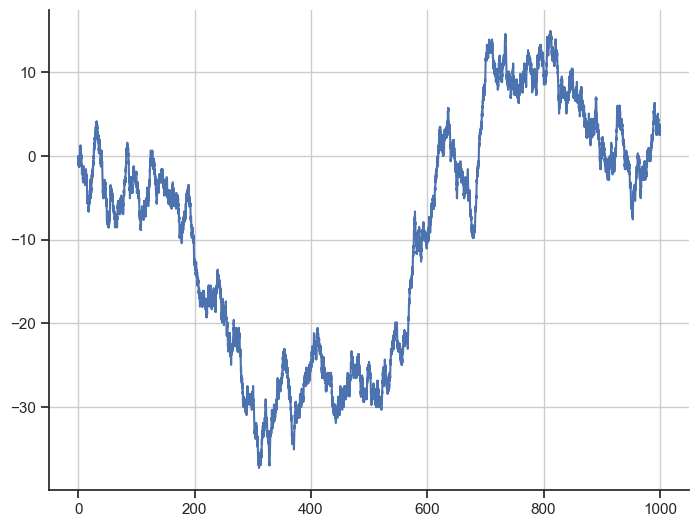

In [549]:
delta_t = 0.1
T = 1000
n = int(T/delta_t)+1
t = np.arange(0,T+delta_t,delta_t)
W = np.zeros(n)
c = np.sqrt(delta_t)
for i in range(1,n):
    Xi = 2*np.random.randint(2)-1
    W[i] = W[i-1]+c*Xi
fig = plt.figure()    
axes = fig.add_axes([-2,2,1,1]) 
axes.grid(True,which='both')
sb.despine(ax=axes,offset=0)
axes.plot(t,W)

# Studying the SDE $dX_t = \mu X_tdt + \sigma X_t dW_t$

## Euler-Maruyama Scheme

In [453]:
mu = 1.5
sigma = 1
s = sigma**2
X0 = 1
T = 1
delta_t = 10**(-2)
def Ito(t,Wt):
    return X0*np.exp((mu-0.5*s)*t+sigma*Wt)

In [454]:
def Euler_Maruyama(delta_t):
    mu = 1.5
    sigma = 1
    X0 = 1
    T = 1
    t = np.arange(0,T+delta_t,delta_t)
    n = len(t)
    X = np.zeros((n))
    X[0] = X0
    Exact = np.zeros((n))
    Exact[0] = X0
    W=0
    for i in range(1,n):
        dW = np.random.normal(loc = 0.0, scale = np.sqrt(delta_t))
        X[i] = X[i-1]+mu*X[i-1]*delta_t + sigma*X[i-1]*dW
        W = W+dW
        Exact[i]=Ito(t[i],W)
    return t,X,Exact  

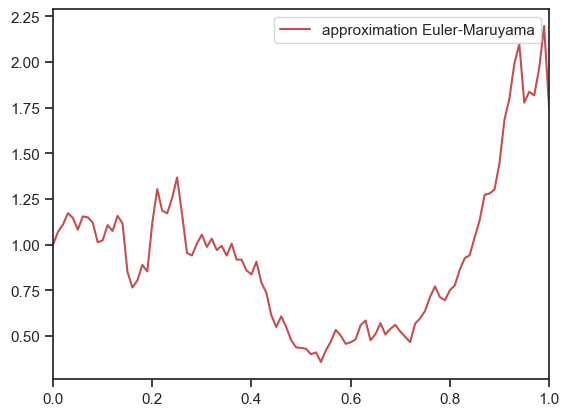

In [457]:
simulations = 1
for j in range(simulations):
    t,X,Exact = Euler_Maruyama(0.01)
    fig, ax = plt.subplots()
    ax.plot(t,X,'r-',label=f'approximation Euler-Maruyama')
    ax.set_xlim(0,1)
    ax.legend()

    


## Milstein Scheme

In [162]:
def Milstein(delta_t):
    mu = 1.5
    sigma = 1
    X0 = 1
    T = 1
    t = np.arange(0,T+delta_t,delta_t)
    n = len(t)
    X = np.zeros((n))
    X[0] = X0
    Exact = np.zeros((n))
    Exact[0] = X0
    W=0
    for i in range(1,n):
        dW = np.random.normal(loc = 0.0, scale = np.sqrt(delta_t))
        x = X[i-1]
        X[i] = x+mu*x*delta_t + sigma*x*dW+0.5*sigma**2*x*(dW**2-delta_t)
        W = W+dW
        Exact[i]=Ito(t[i],W)
    return t,X,Exact  

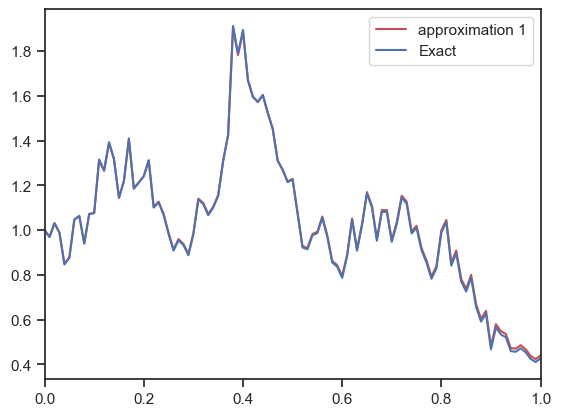

In [550]:
simulations = 1
for j in range(simulations):
    t,X,Exact = Milstein(0.01)
    fig, ax = plt.subplots()
    ax.plot(t,X,'r-',label=f'approximation {j+1}')
    ax.plot(t,Exact,'b-',label=f'Exact')
    ax.set_xlim(0,1)
    ax.legend()

## Strong Convergence

In [552]:
def simulator(simulations,method):
    meanErrors = np.zeros(6)
    if method == "Milstein":
        for u,v in enumerate(delta_t):
            Errors = np.zeros(simulations)
            for j in range(simulations):
                t,X,Exact = Milstein(v)
                Error = np.abs(X[-1]-Exact[-1])
                Errors[j] = Error
            meanErrors[u] = np.mean(Errors)
    elif method == "Euler-Maruyama":
        for u,v in enumerate(delta_t):
            Errors = np.zeros(simulations)
            for k in range(simulations):
                t,X,Exact = Euler_Maruyama(v)
                Error = np.abs(X[-1]-Exact[-1])
                Errors[k] = Error
        meanErrors[u] = np.mean(Errors)
    else:
        print("error, function only accepts methods Euler-Maruyama and Milstein")
    return meanErrors


In [46]:
#errorEM = simulator(100,"Euler-Maruyama")

In [47]:
#errorMil = simulator(100,"Milstein")

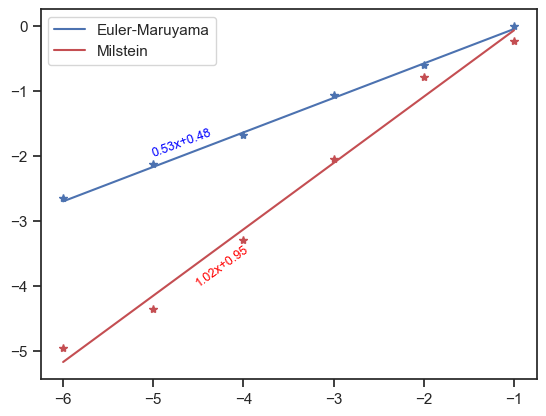

In [81]:
logtime= np.log10(delta_t) 
logerrorEM = np.log10(errorEM)
logerrorMil = np.log10(errorMil)
a1,b1 = np.polyfit(logtime,logerrorEM,deg=1)
a1,b1 = np.round(a1,2),np.round(b1,2)
a2,b2 = np.polyfit(logtime,logerrorMil,deg=1)
a2,b2 = np.round(a2,2),np.round(b2,2)
plt.plot(logtime,logerrorEM ,'b*')
plt.plot(logtime,logerrorMil ,'r*')
plt.plot(logtime,a1*logtime+b1,'b', label = "Euler-Maruyama")
plt.plot(logtime,a2*logtime+b2,'r', label = "Milstein")
plt.legend()
plt.text(-5,-2, f'{a1}x+{b1}',
         color = 'blue', rotation = 27,
         rotation_mode = 'anchor',
         transform_rotates_text = True,size = 9)
plt.text(-4.5,-4, f'{a2}x+{b2}',
         color = 'red', rotation = 45,
         rotation_mode = 'anchor',
         transform_rotates_text = True,size = 9)
plt.show()

## Weak Convergence

In [469]:
mu = 1.5
sigma = 1
X0 = 1
T=0.1
delta_t = [2**(-4),2**(-5),2**(-6),2**(-7),2**(-8),2**(-9),2**(-10)]
expectation = np.exp(mu*T)

In [525]:
def Euler_Maruyama2(delta_t):
    t = np.arange(0,T+delta_t,delta_t)
    n = len(t)
    X = X0
    for i in range(1,n):
        dW = np.random.normal(loc = 0.0, scale = np.sqrt(delta_t))
        X = X+mu*X*delta_t + sigma*X*dW
    return X  

In [461]:
def Milstein2(delta_t):
    t = np.arange(0,T+delta_t,delta_t)
    n = len(t)
    X = X0
    for i in range(1,n):
        dW = np.random.normal(loc = 0.0, scale = np.sqrt(delta_t))
        X = X+mu*X*delta_t + sigma*X*dW+0.5*sigma**2*X*(dW**2-delta_t)
    return X

In [462]:
def simulatorWeak(simulations,method):
    Errormeans = np.zeros(7)
    if method == "Milstein":
        for u,v in enumerate(delta_t):
            x = np.zeros(simulations)
            for j in range(simulations):
                X = Milstein2(v)
                x[j]=X
            Errormeans[u] = np.absolute(expectation - np.mean(x))
            
    elif method == "Euler-Maruyama":
        for u,v in enumerate(delta_t):
            x = np.zeros(simulations)
            for k in range(simulations):
                X = Euler_Maruyama2(v)
                x[k]=X
            Errormeans[u] = np.absolute(expectation - np.mean(x))
    else:
        print("error, function only accepts methods Euler-Maruyama and Milstein")
    return Errormeans

In [310]:
errorEMWeak = simulatorWeak(50000,"Euler-Maruyama")
errorMilWeak = simulatorWeak(50000,"Milstein")


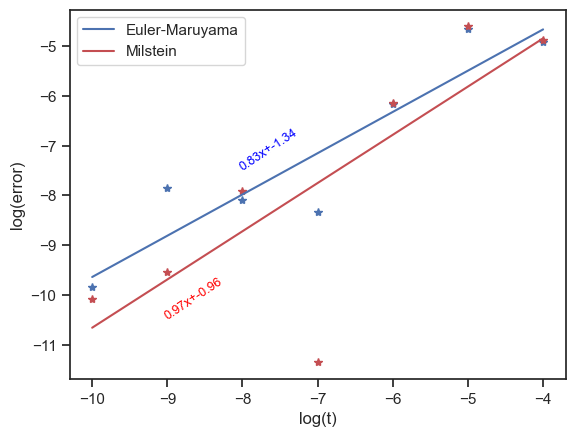

In [470]:
logtime = np.log2(delta_t)
logerrorEMWeak = np.log2(errorEMWeak)
logerrorMilWeak = np.log2(errorMilWeak)
a1,b1 = np.polyfit(logtime,logerrorEMWeak,deg=1)
a1,b1 = np.round(a1,2),np.round(b1,2)
a2,b2 = np.polyfit(logtime,logerrorMilWeak,deg=1)
a2,b2 = np.round(a2,2),np.round(b2,2)
plt.plot(logtime,logerrorEMWeak ,'b*')
plt.plot(logtime,logerrorMilWeak ,'r*')
plt.plot(logtime,a1*logtime+b1,'b', label = "Euler-Maruyama")
plt.plot(logtime,a2*logtime+b2,'r', label = "Milstein")
plt.legend()
plt.xlabel("log(t)")
plt.ylabel("log(error)")
plt.text(-8,-7.5, f'{a1}x+{b1}',
         color = 'blue', rotation = 45,
         rotation_mode = 'anchor',
         transform_rotates_text = True,size = 9)
plt.text(-9,-10.5, f'{a2}x+{b2}',
         color = 'red', rotation = 45,
         rotation_mode = 'anchor',
         transform_rotates_text = True,size = 9)
plt.show()

In [304]:
print(errorEMWeak,errorMilWeak)

[0.03625989 0.04133886 0.01457654 0.00155877 0.00405259 0.00057944] [0.03146922 0.03878537 0.01340736 0.00518884 0.00568187 0.00130901]


## Stratonovich Noise

In [472]:
mu = 1.5
sigma = 1
X0 = 1
T = 1
def Euler_Maruyama_Stratonovich(delta_t):
    t = np.arange(0,T+delta_t,delta_t)
    n = len(t)
    X = np.zeros((n))
    X[0] = X0
    W=0
    for i in range(1,n):
        dW = np.random.normal(loc = 0.0, scale = np.sqrt(delta_t))
        x = X[i-1]
        X[i] = x+(mu+0.5*sigma**2)*x*delta_t + sigma*x*dW
        W = W+dW
    return t,X  

In [313]:
def Euler_Maruyama3(delta_t):
    t = np.arange(0,T+delta_t,delta_t)
    n = len(t)
    X = np.zeros((n))
    X[0] = X0
    W=0
    for i in range(1,n):
        dW = np.random.normal(loc = 0.0, scale = np.sqrt(delta_t))
        x = X[i-1]
        X[i] = x+mu*x*delta_t + sigma*x*dW
        W = W+dW
    return t,X  

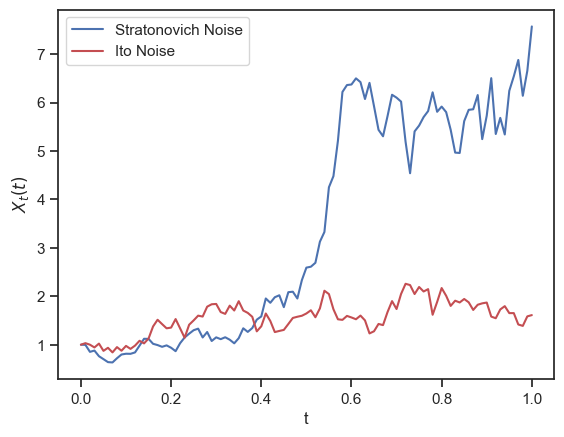

In [473]:
delta_t = 0.01
t,X = Euler_Maruyama_Stratonovich(delta_t)
_,Y = Euler_Maruyama3(delta_t)
plt.plot(t,X,'b', label = "Stratonovich Noise")
plt.plot(t,Y,'r', label = "Ito Noise")
plt.xlabel(r"t")
plt.ylabel(r'$X_t(t)$')
plt.legend()

In [387]:
def simulator2(simulations,delta_t):
    r = int(1/delta_t)+1
    x = np.zeros((simulations,r))
    y = np.zeros((simulations,r))
    A = np.zeros(r)
    B = np.zeros(r)
    for k in range(simulations):
        _,X,Exact = Euler_Maruyama(delta_t)
        _,Y = Euler_Maruyama_Stratonovich(delta_t)
        x[k:k+1,:]=X
        y[k:k+1,:]=Y
    
    for j in range(r):
        a = x[:,j:j+1]
        b = y[:,j:j+1]
        A[j] = np.mean(a)
        B[j] = np.mean(b)
    return A,B

In [395]:
A,B = simulator2(10000,0.01)

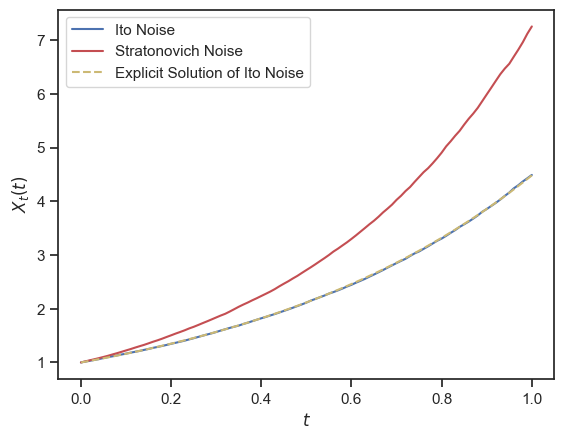

In [475]:
t = np.arange(0,T+delta_t,delta_t)
expected = np.exp(mu*t)
plt.plot(t,A,'b', label = "Ito Noise")
plt.plot(t,B,'r', label = "Stratonovich Noise")
plt.plot(t,expected,'y--',label = "Explicit Solution of Ito Noise")
plt.xlabel(r'$t$')
plt.ylabel(r'$X_t(t)$')
plt.legend()

## $E[X_t^2]$ for $t=0.1$

In [540]:
mu = 1.5
sigma = 1
X0 = 1
T=0.1
delta_t = 0.001
expectation = np.exp((2*mu+sigma**2)*T)
simulations = [2**n for n in range(3,10)]
def simulator3(simulations):
    accuracy = np.zeros(7)
    for u,v in enumerate(simulations):
        x = np.zeros(v)
        for k in range(v):
            X = Euler_Maruyama2(delta_t)
            x[k]=X**2
        accuracy[u] = np.absolute(expectation-np.mean(x))
    return accuracy

In [541]:
a = simulator3(simulations)

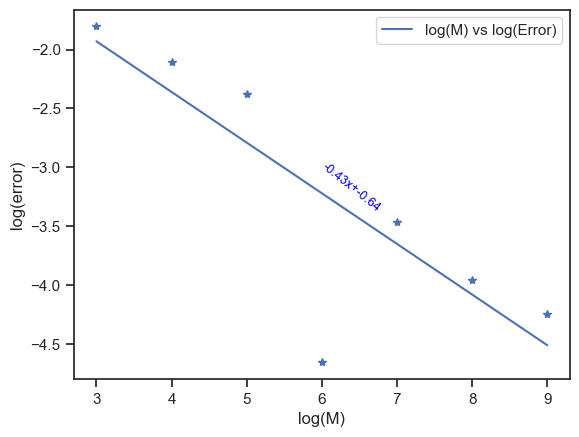

In [545]:
logsimulations = np.log2(simulations)
logerror = np.log2(a)
a1,b1 = np.polyfit(logsimulations,logerror,deg=1)
a1,b1 = np.round(a1,2),np.round(b1,2)
plt.plot(logsimulations,logerror ,'b*')
plt.plot(logsimulations,a1*logsimulations+b1,'b', label = "log(M) vs log(Error)")
plt.legend()
plt.xlabel("log(M)")
plt.ylabel("log(error)")
plt.text(6,-3, f'{a1}x+{b1}',
         color = 'blue', rotation = -27,
         rotation_mode = 'anchor',
         transform_rotates_text = True,size = 9)
plt.show()

In [537]:
a

array([0.10685362, 0.06770975, 0.05364693, 0.00131253, 0.00296204,
       0.00239439])

# Exercise 3: Studying $dy=(\mu ty-y^3)dt+bdW_t$

In [3]:
def Euler_Maruyama4(b,Y0,T,delta_t):
    mu = 0.03
    b = b
    Y0 = Y0
    T = T
    delta_t = delta_t
    t = np.arange(0,T+delta_t,delta_t)
    A = np.sqrt(mu*t)
    B = -A
    C = 0*t
    n = len(t)
    Y = np.zeros((n))
    Y[0] = Y0
    for i in range(1,n):
        dW = np.random.normal(loc = 0.0, scale = np.sqrt(delta_t))
        y = Y[i-1]
        S = t[i-1]
        Y[i] = y+(mu*S*y-y**3)*delta_t+b*dW
    return t,Y,A,B,C 

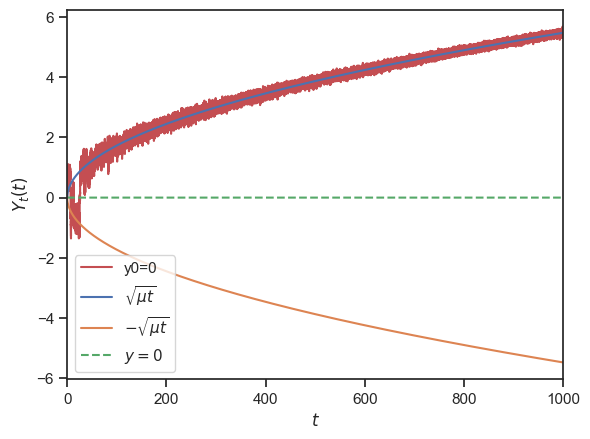

In [6]:
simulations = 1
b = 0.5
Y0 = 0
T = 1000
delta_t = 0.001
for j in range(simulations):
    t,Y,A,B,C = Euler_Maruyama4(b,Y0,T,delta_t)
    fig, ax = plt.subplots()
    ax.plot(t,Y,'r-',label=f'y0=0')
    ax.plot(t,A,label=r'$\sqrt{\mu t}$')
    ax.plot(t,B,label=r'$-\sqrt{\mu t}$')
    ax.plot(t,C,'g--',label=r'$y=0$')
    ax.set_xlim(0,T)
    plt.xlabel(r'$t$')
    plt.ylabel(r'$Y_t(t)$')
    ax.legend()
